**THIS IS WHERE I SET UP THE ENVIRONMENT FOR THE DRONES**

Plan about milestones:

- 2d (3d drone top view) + static first
	- static obstacles
	- obj moving 1d
	- obj moving 2d
- 3d version
	- static obstacles
	- obj moving 1d
	- obj moving 2d

I will try to be using gym-pybullet-drones

In [1]:
#!pip install numpy matplotlib

In [2]:
#!pip install scipy pillow gym 

In [3]:
#!pip install pybullet==3.1.9 


In [4]:
#!pip install gym-pybullet-drones/

In [5]:
import numpy as np
import pybullet as p
import matplotlib.pyplot as plt
from gym_pybullet_drones.envs.HoverAviary import HoverAviary #environment
from gym_pybullet_drones.utils.enums import DroneModel

**Make top-view POV**

- make the camera look down

In [6]:
def get_topdown_view(center=[0, 0, 0], height=5.0, size=(640, 640)):
    """top view of the scene"""
    view_matrix = p.computeViewMatrixFromYawPitchRoll(
        cameraTargetPosition=center,#center is the point towards which the camera will be directed to
        distance=height, #how far the camera is from the point it's observing
        yaw=0, #horizontal rotation around the "up" axis (defined in the last parameter)
        pitch=-89.9,  #looking down (if i put 90 degrees then i might get weird block/freeze based on what I found online)
        roll=0, #camera rotation around its viewing diretion (not clear but i put 0 so that it doesn't rotate)
        upAxisIndex=2 #defining which index in the [x, y, z] represents the "up" (second index is z)
    )
    
    proj_matrix = p.computeProjectionMatrixFOV(
        fov=60, aspect=1.0, nearVal=0.1, farVal=100.0
    )
    #fox: how wide the camera can see - like zoom level
    #aspect: aspect ratio, 1.0 is a square
    #nerVal: objects closer than this aren't rendered - since i am just trying to get this to work i put the value rlly low
    #favVal: objects farther than this aren't rendered  since i am just trying to get this to work i put the value rlly high
    
    _, _, rgb, _, _ = p.getCameraImage(
        width=size[0], height=size[1],
        viewMatrix=view_matrix,
        projectionMatrix=proj_matrix,
        renderer=p.ER_BULLET_HARDWARE_OPENGL
    )
    #width: image width in pixels
    #height: image height in pixels
    #viewMatrix: the matrix that we see from avobe - what the camera sees - translates what is there in the simulation to the view of the camera
    #projectionMatrix: flattens the 3d space into 2d coordinates 
    #renderer: rendering engine - OpenGL
    
    return np.array(rgb).reshape(size[1], size[0], 4)[:, :, :3] #reshaping the rgb data into np array for manipulation purposes
    #pybullet returns the image as a flat 1D array of pixel values so I need to give it the width, height and the 4 channels: RBG + ALpha 
    #i am slicing the 4 channels to only give me the RGB tho because Alpha is about transparency information which i don't think i need? 

**Create environment**
- HoverAviary is env
- DroneModel is the agent

In [7]:
env = HoverAviary(
    drone_model=DroneModel.CF2X,
    initial_xyzs=np.array([[0, 0, 1.0]]),
    gui=True  #set False if we don't want the buttons and stuff in the interface (maybe for simulations)
)

obs = env.reset()
print("Environment done")

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
viewMatrix (0.642787516117096, -0.4393851161003113, 0.6275069713592529, 0.0, 0.766044557094574, 0.36868777871131897, -0.5265407562255859, 0.0, -0.0, 0.8191521167755127, 0.5735764503479004, 0.0, 2.384185791015625e-07, 2.384185791015625e-07, -5.000000476837158, 1.0)
projectionMatrix (0.7499999403953552, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, -1.0000200271606445, -1.0, 0.0, 0.0, -0.02000020071864128, 0.0)
viewMatrix (0.642787516117096, -0.4393851161003113, 0.6275069713592529, 0.0, 0.766044557094574, 0.36868777871131897, -0.5265407562255859, 0.0, -0.0, 0.8191521167755127, 

c:\Users\Teodora\OneDrive\Documents\GitHub\Thesis\.venv\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\Teodora\OneDrive\Documents\GitHub\Thesis\.venv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Environment done


**Run and capture the image - check if works**

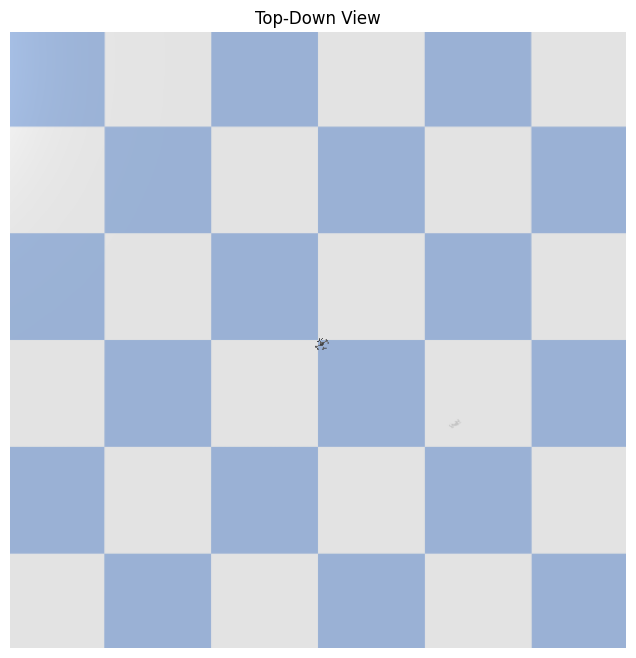

In [8]:
#run simulation
for i in range(100):
    action = np.array([[0, 0, 1, 0]])  # [vx, vy, vz, yaw_rate]
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        break
#i need to run this to initialize the physics of the environment - i made the drone go a bit upward every time so that I can see it 
#otherwise it would have been at ground level and even smaller than it is now 

#capture view
image = get_topdown_view(center=[0, 0, 0], height=5.0)

#display
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title('Top-Down View')
plt.axis('off')
plt.show()

**Close env**

In [9]:
env.close()